# 08 - Adversarial Revisions

This notebook addresses critical issues raised during adversarial review of the
plant microbiome ecotype classification (25,660 bacterial species into
beneficial / pathogenic / dual-nature / neutral cohorts).

**Key concerns tested here:**

1. **T3SS / T6SS sensitivity** -- are dual-nature assignments inflated by counting
   secretion systems as pathogenic?
2. **PGP vs pathogen score scatter** -- visual validation with known organisms
3. **Marker co-occurrence drivers** -- what actually makes species "dual-nature"?
4. **Plant-filtered genus dossiers** -- remove non-plant genera from the top-30
5. **Genome-size normalization** -- do large genomes accumulate markers by chance?
6. **PERMDISP test** -- are cohort differences in marker profiles confounded by
   dispersion?
7. **Negative controls** -- do non-plant genera get classified as beneficial?
8. **Family-level phylogenetic control** -- do novel OGs survive family-level
   confounding?
9. **Predictive classifier** -- can markers predict compartment or cohort?
10. **Pfam pipeline investigation** -- do target Pfams exist in the database?
11. **HGT per-marker transposase co-occurrence**
12. **HGT contig co-location analysis**

## 1. Setup and Load Data

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

from berdl_notebook_utils.setup_spark_session import get_spark_session

# ---- paths ----------------------------------------------------------------
_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'plant_microbiome_ecotypes')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'plant_microbiome_ecotypes')
DATA    = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')
os.makedirs(FIGURES, exist_ok=True)

# ---- load CSVs ------------------------------------------------------------
smm   = pd.read_csv(os.path.join(DATA, 'species_marker_matrix.csv'))
coho  = pd.read_csv(os.path.join(DATA, 'cohort_assignments.csv'))
scomp = pd.read_csv(os.path.join(DATA, 'species_compartment.csv'))
scm   = pd.read_csv(os.path.join(DATA, 'species_cohort_markers.csv'))
pstats = pd.read_csv(os.path.join(DATA, 'pangenome_stats.csv'))
mgc   = pd.read_csv(os.path.join(DATA, 'marker_gene_clusters.csv'))
trans = pd.read_csv(os.path.join(DATA, 'transposase_singletons.csv'))
enrich = pd.read_csv(os.path.join(DATA, 'enrichment_results.csv'))
novel = pd.read_csv(os.path.join(DATA, 'novel_plant_markers.csv'))
cprof = pd.read_csv(os.path.join(DATA, 'compartment_profiles.csv'))
gdoss = pd.read_csv(os.path.join(DATA, 'genus_dossiers.csv'))
garch = pd.read_csv(os.path.join(DATA, 'genomic_architecture.csv'))

print(f"species_marker_matrix : {smm.shape}")
print(f"cohort_assignments    : {coho.shape}")
print(f"species_compartment   : {scomp.shape}")
print(f"pangenome_stats       : {pstats.shape}")
print(f"marker_gene_clusters  : {mgc.shape}")
print(f"transposase_singletons: {trans.shape}")
print(f"novel_plant_markers   : {novel.shape}")
print(f"genus_dossiers        : {gdoss.shape}")
print()
print('Cohort distribution (original):')
if 'cohort' in coho.columns:
    print(coho['cohort'].value_counts())
elif 'marker_cohort' in smm.columns:
    print(smm['marker_cohort'].value_counts())

species_marker_matrix : (25660, 54)
cohort_assignments    : (25660, 12)
species_compartment   : (26511, 8)
pangenome_stats       : (27702, 6)
marker_gene_clusters  : (588098, 8)
transposase_singletons: (986464, 7)
novel_plant_markers   : (50, 17)
genus_dossiers        : (30, 13)

Cohort distribution (original):
cohort
neutral        9742
pathogenic     7572
dual_nature    6465
beneficial     1881
Name: count, dtype: int64


## 2. T3SS / T6SS Sensitivity Analysis

**Concern:** The dual-nature finding (60-85% of plant species) may be inflated
because T3SS and T6SS are classified as "pathogenic" markers.  Many beneficial
plant-associated bacteria carry these secretion systems for commensal
colonization, not virulence.

We reclassify T3SS, T3SS-product, T6SS, T6SS-product, and T2SS as
"colonization" markers and recompute cohort assignments.

=== Cohort Distribution: Original vs Revised (T3SS/T6SS removed from pathogenic) ===
               Original  Revised  Original_pct  Revised_pct
dual_nature       15474    16293          60.3         63.5
neutral             971     1675           3.8          6.5
pathogen_only      8023     2275          31.3          8.9
pgp_only           1192     5417           4.6         21.1



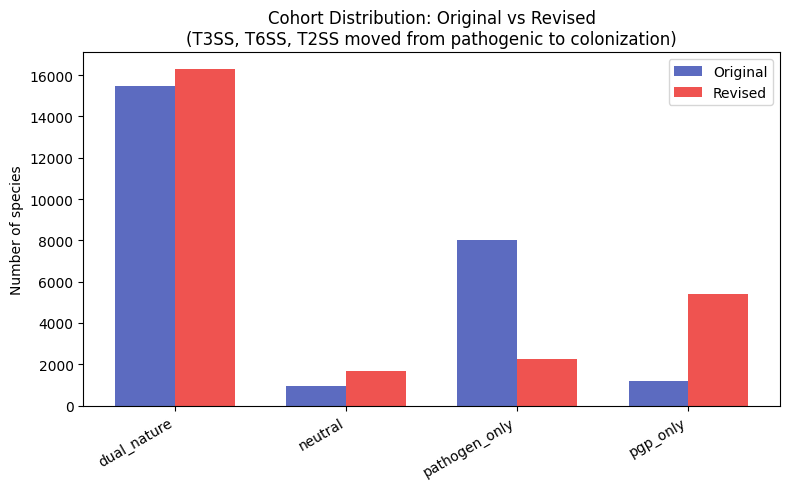


Plant-associated species (n=1115):
cohort_revised
dual_nature      959
pgp_only         129
pathogen_only     20
neutral            7
Name: count, dtype: int64

Revised dual-nature fraction for plant species: 959/1115 = 86.0%


In [2]:
# -- Define revised pathogenic markers (secretion systems moved out) ---------
ORIGINAL_PATHOGENIC = [
    'cwde_cellulase', 'cwde_pectinase', 'effector', 'coronatine_toxin',
    'phytotoxin', 'other_pathogenic', 't4ss', 't3ss', 't3ss_product',
    't6ss', 't6ss_product', 't2ss',
]
REVISED_PATHOGENIC = [
    'cwde_cellulase', 'cwde_pectinase', 'effector', 'coronatine_toxin',
    'phytotoxin', 'other_pathogenic', 't4ss',
]
MOVED_TO_COLONIZATION = ['t3ss', 't3ss_product', 't6ss', 't6ss_product', 't2ss']

PGP_MARKERS = [
    'acc_deaminase', 'acetoin_butanediol', 'biofilm', 'chemotaxis',
    'dapg_biocontrol', 'flagella', 'hydrogen_cyanide', 'iaa_biosynthesis',
    'nitrogen_fixation', 'phenazine', 'phosphate_solubilization',
    'quorum_sensing', 'siderophore',
]

# Boolean presence columns
pgp_pres_cols = [c + '_present' for c in PGP_MARKERS]
orig_path_pres_cols = [c + '_present' for c in ORIGINAL_PATHOGENIC]
rev_path_pres_cols  = [c + '_present' for c in REVISED_PATHOGENIC]

# Ensure columns exist
pgp_pres_cols  = [c for c in pgp_pres_cols if c in smm.columns]
rev_path_pres_cols = [c for c in rev_path_pres_cols if c in smm.columns]

smm['has_pgp_any']    = smm[pgp_pres_cols].sum(axis=1) > 0
smm['has_path_orig']  = smm[[c + '_present' for c in ORIGINAL_PATHOGENIC if c + '_present' in smm.columns]].sum(axis=1) > 0
smm['has_path_rev']   = smm[rev_path_pres_cols].sum(axis=1) > 0
smm['n_pathogen_revised'] = smm[rev_path_pres_cols].sum(axis=1).astype(int)

# Revised cohort assignment
def assign_revised(row):
    pgp  = row['has_pgp_any']
    path = row['has_path_rev']
    if pgp and path:
        return 'dual_nature'
    elif pgp:
        return 'pgp_only'
    elif path:
        return 'pathogen_only'
    return 'neutral'

smm['cohort_revised'] = smm.apply(assign_revised, axis=1)

# Comparison table
orig_counts = smm['marker_cohort'].value_counts()
rev_counts  = smm['cohort_revised'].value_counts()
comp = pd.DataFrame({'Original': orig_counts, 'Revised': rev_counts}).fillna(0).astype(int)
comp['Original_pct'] = (comp['Original'] / comp['Original'].sum() * 100).round(1)
comp['Revised_pct']  = (comp['Revised']  / comp['Revised'].sum()  * 100).round(1)
# Reorder rows
for label in ['dual_nature', 'pgp_only', 'pathogen_only', 'neutral', 'beneficial']:
    pass  # just ensure they appear
print('=== Cohort Distribution: Original vs Revised (T3SS/T6SS removed from pathogenic) ===')
print(comp.to_string())
print()

# ---- Side-by-side bar chart -----------------------------------------------
labels = sorted(set(list(orig_counts.index) + list(rev_counts.index)))
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, [orig_counts.get(l, 0) for l in labels], w, label='Original', color='#5C6BC0')
ax.bar(x + w/2, [rev_counts.get(l, 0) for l in labels],  w, label='Revised',  color='#EF5350')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Number of species')
ax.set_title('Cohort Distribution: Original vs Revised\n(T3SS, T6SS, T2SS moved from pathogenic to colonization)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'sensitivity_t3ss_t6ss.png'), dpi=150)
plt.show()

# ---- Plant-associated only ------------------------------------------------
PLANT_COMPS = {'root', 'rhizosphere', 'phyllosphere', 'endophyte', 'plant_other'}
smm_comp = smm.merge(
    scomp[['gtdb_species_clade_id', 'dominant_compartment']],
    on='gtdb_species_clade_id', how='left'
)
plant_mask = smm_comp['dominant_compartment'].isin(PLANT_COMPS)
plant_rev = smm_comp.loc[plant_mask, 'cohort_revised'].value_counts()
n_plant = plant_mask.sum()
dual_plant_rev = plant_rev.get('dual_nature', 0)
print(f'\nPlant-associated species (n={n_plant}):')
print(plant_rev)
print(f'\nRevised dual-nature fraction for plant species: '
      f'{dual_plant_rev}/{n_plant} = {dual_plant_rev/n_plant*100:.1f}%')

## 3. PGP vs Pathogen Score Scatter Plot

Composite PGP score (x-axis) vs composite pathogen score (y-axis) for all
25,660 species, colored by cohort assignment. Known model organisms are
annotated.

  [warn] No match for Pseudomonas_syringae


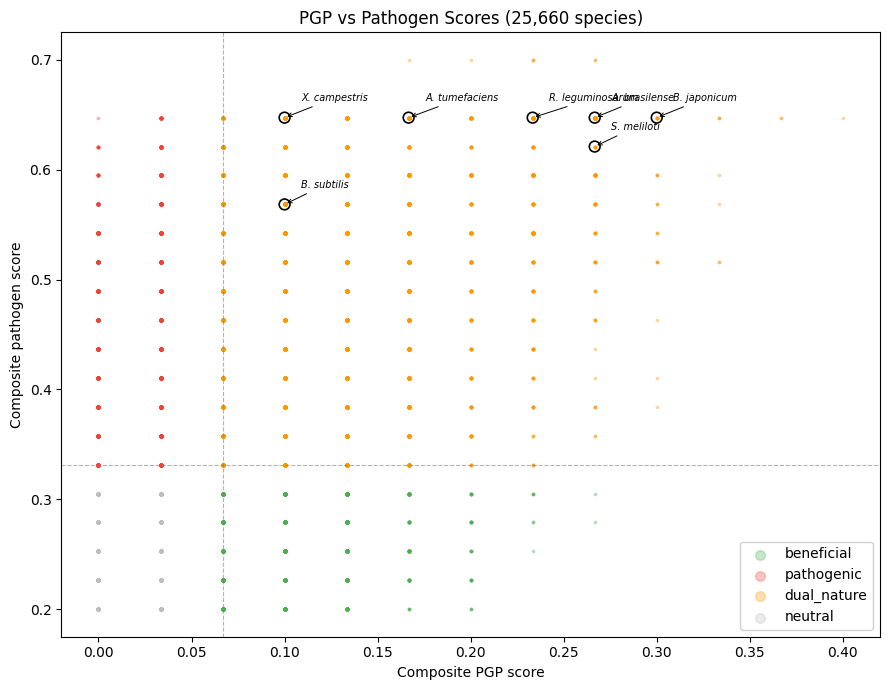

In [3]:
cohort_colors = {
    'beneficial':    '#4CAF50',
    'pgp_only':      '#4CAF50',
    'pathogenic':    '#F44336',
    'pathogen_only': '#F44336',
    'dual_nature':   '#FF9800',
    'neutral':       '#BDBDBD',
}

fig, ax = plt.subplots(figsize=(9, 7))

cohort_col = 'cohort' if 'cohort' in coho.columns else 'marker_cohort'

for cohort_name, color in cohort_colors.items():
    mask = coho[cohort_col] == cohort_name
    if mask.sum() == 0:
        continue
    ax.scatter(
        coho.loc[mask, 'composite_pgp'],
        coho.loc[mask, 'composite_pathogen'],
        c=color, s=3, alpha=0.3, label=cohort_name, rasterized=True,
    )

# Threshold lines (median of non-zero scores)
pgp_nz = coho.loc[coho['composite_pgp'] > 0, 'composite_pgp']
path_nz = coho.loc[coho['composite_pathogen'] > 0, 'composite_pathogen']
if len(pgp_nz) > 0:
    ax.axvline(pgp_nz.median(), ls='--', lw=0.8, color='grey', alpha=0.6)
if len(path_nz) > 0:
    ax.axhline(path_nz.median(), ls='--', lw=0.8, color='grey', alpha=0.6)

# Annotate known organisms
KNOWN = [
    ('Rhizobium_leguminosarum',   'R. leguminosarum'),
    ('Bradyrhizobium_japonicum',  'B. japonicum'),
    ('Pseudomonas_syringae',      'P. syringae'),
    ('Xanthomonas_campestris',    'X. campestris'),
    ('Bacillus_subtilis',         'B. subtilis'),
    ('Agrobacterium_tumefaciens', 'A. tumefaciens'),
    ('Sinorhizobium_meliloti',    'S. meliloti'),
    ('Azospirillum_brasilense',   'A. brasilense'),
]
for pattern, label in KNOWN:
    matches = coho[coho['gtdb_species_clade_id'].str.contains(pattern, na=False)]
    if len(matches) == 0:
        print(f'  [warn] No match for {pattern}')
        continue
    row = matches.iloc[0]
    ax.scatter(row['composite_pgp'], row['composite_pathogen'],
               s=60, edgecolors='black', facecolors='none', linewidths=1.2, zorder=5)
    ax.annotate(
        label,
        xy=(row['composite_pgp'], row['composite_pathogen']),
        xytext=(12, 12), textcoords='offset points',
        fontsize=7, fontstyle='italic',
        arrowprops=dict(arrowstyle='->', color='black', lw=0.7),
    )

ax.set_xlabel('Composite PGP score')
ax.set_ylabel('Composite pathogen score')
ax.set_title('PGP vs Pathogen Scores (25,660 species)')
ax.legend(markerscale=4, framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'pgp_vs_pathogen_scatter.png'), dpi=150)
plt.show()

## 4. Marker Co-occurrence Analysis: What Drives Dual-Nature?

For all species classified as dual-nature, compute the prevalence of each
individual marker.  This reveals which specific markers are responsible for
the dual classification.

Dual-nature species (original): 15474


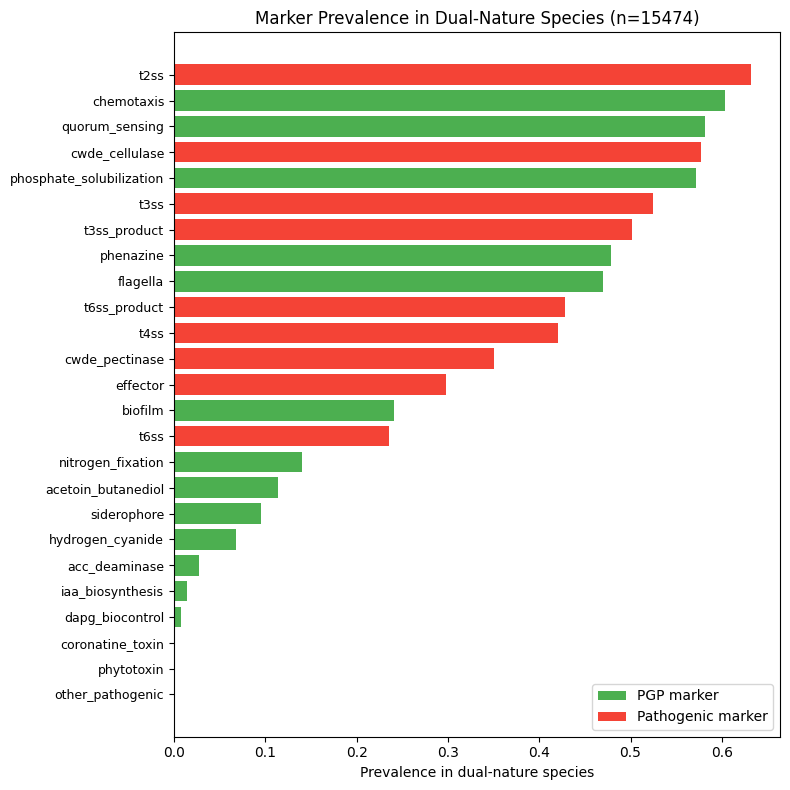


If T3SS + T6SS are removed from pathogenic classification, 2531/15474 (16.4%) of dual-nature species would be reclassified as PGP-only.


In [4]:
# Identify dual-nature species (original classification)
dual_mask = smm['marker_cohort'] == 'dual_nature'
n_dual = dual_mask.sum()
print(f'Dual-nature species (original): {n_dual}')

# All boolean _present columns
all_present = [c for c in smm.columns if c.endswith('_present')]

# Compute prevalence in dual-nature species
prev = smm.loc[dual_mask, all_present].mean().sort_values(ascending=True)
prev.index = [c.replace('_present', '') for c in prev.index]

# Classify each marker as PGP or pathogenic for coloring
pgp_set  = set(PGP_MARKERS)
path_set = set(ORIGINAL_PATHOGENIC)
colors = []
for m in prev.index:
    if m in pgp_set:
        colors.append('#4CAF50')
    elif m in path_set:
        colors.append('#F44336')
    else:
        colors.append('#9E9E9E')

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(range(len(prev)), prev.values, color=colors)
ax.set_yticks(range(len(prev)))
ax.set_yticklabels(prev.index, fontsize=9)
ax.set_xlabel('Prevalence in dual-nature species')
ax.set_title(f'Marker Prevalence in Dual-Nature Species (n={n_dual})')
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#4CAF50', label='PGP marker'),
    Patch(facecolor='#F44336', label='Pathogenic marker'),
], loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'dual_nature_marker_drivers.png'), dpi=150)
plt.show()

# How many dual-nature species would be reclassified if T3SS+T6SS removed?
# A dual-nature species is reclassified as PGP-only if its ONLY pathogenic
# markers are in the moved set.
moved_pres = [c + '_present' for c in MOVED_TO_COLONIZATION if c + '_present' in smm.columns]
rev_pres   = [c + '_present' for c in REVISED_PATHOGENIC if c + '_present' in smm.columns]

dual_df = smm.loc[dual_mask].copy()
has_only_moved_path = (dual_df[rev_pres].sum(axis=1) == 0)
n_reclass = has_only_moved_path.sum()
print(f'\nIf T3SS + T6SS are removed from pathogenic classification, '
      f'{n_reclass}/{n_dual} ({n_reclass/n_dual*100:.1f}%) of dual-nature species '
      f'would be reclassified as PGP-only.')

## 5. Plant-Filtered Genus Dossiers

The original top-30 genus dossiers include non-plant genera (e.g.,
Prevotella, Streptococcus, Bifidobacterium).  Here we filter to genera
whose primary compartment is a plant or soil compartment.

In [5]:
PLANT_SOIL = {'root', 'rhizosphere', 'phyllosphere', 'endophyte', 'plant_other', 'soil'}

# Try to use primary_compartment from genus_dossiers first
if 'primary_compartment' in gdoss.columns:
    plant_genera = gdoss[gdoss['primary_compartment'].isin(PLANT_SOIL)].copy()
else:
    # Rebuild from cohort_assignments + species_compartment
    coho_comp = coho.merge(
        scomp[['gtdb_species_clade_id', 'dominant_compartment']],
        on='gtdb_species_clade_id', how='left',
    )
    # Find genera where majority of species are in plant/soil compartments
    genus_comp = coho_comp.groupby('genus')['dominant_compartment'].apply(
        lambda x: x.value_counts().idxmax()
    ).reset_index()
    genus_comp.columns = ['genus', 'primary_compartment']
    plant_genus_list = genus_comp[genus_comp['primary_compartment'].isin(PLANT_SOIL)]['genus'].tolist()
    plant_genera = gdoss[gdoss['genus'].isin(plant_genus_list)].copy()

# Top 30 by species count
if 'n_species' in plant_genera.columns:
    top30_plant = plant_genera.nlargest(30, 'n_species')
else:
    # Count from cohort_assignments
    genus_counts = coho['genus'].value_counts().reset_index()
    genus_counts.columns = ['genus', 'n_species_total']
    plant_genera = plant_genera.merge(genus_counts, on='genus', how='left')
    top30_plant = plant_genera.nlargest(30, 'n_species_total')

display_cols = [c for c in top30_plant.columns if c not in ['dual_assessment']]
print(f'Plant/soil-filtered genus dossiers (top 30 by species count):')
print(top30_plant[display_cols].to_string(index=False))

out_path = os.path.join(DATA, 'genus_dossiers_plant_only.csv')
top30_plant.to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')

Plant/soil-filtered genus dossiers (top 30 by species count):
              genus dominant_cohort primary_compartment  n_species  mean_pgp_score  mean_pathogen_score  mean_composite_pgp  mean_composite_pathogen  mean_core_fraction  mean_complementarity                                                           pgp_markers                                                             pathogen_markers
    g__Streptomyces     dual_nature                soil        316        2.500000            11.863924            0.083333                 0.512209                 NaN                   NaN                                   phenazine, phosphate_solubilization           cwde_cellulase, cwde_pectinase, effector, t2ss, t3ss, t6ss_product
  g__Bradyrhizobium     dual_nature                root         76        6.118421            13.592105            0.203947                 0.557687                 NaN                   NaN acc_deaminase, nitrogen_fixation, phenazine, phosphate_solubilization  

## 6. Genome Size Normalization

**Concern:** Larger genomes (more gene clusters) may accumulate more marker
genes by chance, inflating dual-nature classification.  We test the
correlation between genome size and marker count and check whether
normalization changes cohort assignments.

Genome size correlation: r=0.4356, p=0.00e+00
Species with pangenome data: 25660


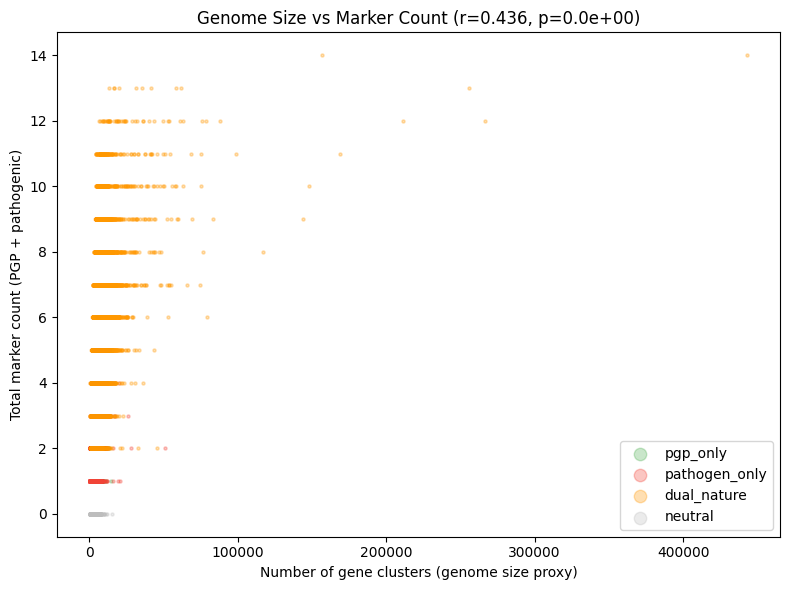


Original vs Genome-Size-Normalized cohort (cross-tab):
cohort_norm    dual_nature  neutral  pathogen_only  pgp_only    All
marker_cohort                                                      
dual_nature           4341     5006           2919      3208  15474
neutral                  0      971              0         0    971
pathogen_only            0     3540           4483         0   8023
pgp_only                 0      410              0       782   1192
All                   4341     9927           7402      3990  25660


In [6]:
# Merge pangenome stats with marker matrix
merged = smm.merge(
    pstats[['gtdb_species_clade_id', 'no_gene_clusters']],
    on='gtdb_species_clade_id', how='inner',
)
merged['total_markers'] = merged['n_pgp_functions'] + merged['n_pathogen_functions']
merged['markers_per_1000_clusters'] = (
    merged['total_markers'] / merged['no_gene_clusters'] * 1000
)

# Correlation
valid = merged.dropna(subset=['no_gene_clusters', 'total_markers'])
_corr = stats.pearsonr(valid['no_gene_clusters'], valid['total_markers'])
genome_r = float(_corr.statistic) if hasattr(_corr, 'statistic') else float(_corr[0])
genome_p = float(_corr.pvalue) if hasattr(_corr, 'pvalue') else float(_corr[1])
print(f'Genome size correlation: r={genome_r:.4f}, p={genome_p:.2e}')
print(f'Species with pangenome data: {len(merged)}')

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
for cohort_name, color in cohort_colors.items():
    mask = merged['marker_cohort'] == cohort_name
    if mask.sum() == 0:
        continue
    ax.scatter(
        merged.loc[mask, 'no_gene_clusters'],
        merged.loc[mask, 'total_markers'],
        c=color, s=5, alpha=0.3, label=cohort_name, rasterized=True,
    )
ax.set_xlabel('Number of gene clusters (genome size proxy)')
ax.set_ylabel('Total marker count (PGP + pathogenic)')
ax.set_title(f'Genome Size vs Marker Count (r={genome_r:.3f}, p={genome_p:.1e})')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'genome_size_vs_markers.png'), dpi=150)
plt.show()

# Recompute cohorts with normalized scores
# Normalized PGP and pathogen scores
merged['pgp_norm']  = merged['n_pgp_functions'] / merged['no_gene_clusters'] * 1000
merged['path_norm'] = merged['n_pathogen_functions'] / merged['no_gene_clusters'] * 1000

# Use presence-based cohort assignment (same as original) since presence
# is not affected by normalization.  Instead check whether ranking changes
# by using quartile-based thresholds on normalized scores.
pgp_thresh  = merged.loc[merged['n_pgp_functions'] > 0, 'pgp_norm'].median()
path_thresh = merged.loc[merged['n_pathogen_functions'] > 0, 'path_norm'].median()

def assign_norm(row):
    if row['pgp_norm'] > pgp_thresh and row['path_norm'] > path_thresh:
        return 'dual_nature'
    elif row['pgp_norm'] > pgp_thresh:
        return 'pgp_only'
    elif row['path_norm'] > path_thresh:
        return 'pathogen_only'
    return 'neutral'

merged['cohort_norm'] = merged.apply(assign_norm, axis=1)

# Compare
ct = pd.crosstab(merged['marker_cohort'], merged['cohort_norm'],
                 margins=True)
print('\nOriginal vs Genome-Size-Normalized cohort (cross-tab):')
print(ct)

## 7. PERMDISP Test

Test whether between-cohort differences in binary marker profiles could be
driven by unequal dispersion (heterogeneity of variance in multivariate
space) rather than genuine location shifts.  We use a Jaccard distance
matrix and compare within-group dispersions.

In [7]:
# Build binary marker matrix for plant compartments
pres_cols = [c for c in smm.columns if c.endswith('_present')]

smm_with_comp = smm.merge(
    scomp[['gtdb_species_clade_id', 'dominant_compartment']],
    on='gtdb_species_clade_id', how='left',
)
plant_comps = {'root', 'rhizosphere', 'phyllosphere', 'endophyte'}
plant_df = smm_with_comp[smm_with_comp['dominant_compartment'].isin(plant_comps)].copy()
print(f'Plant species for PERMDISP: {len(plant_df)}')

# Subsample for computational tractability if needed
MAX_N = 3000
if len(plant_df) > MAX_N:
    plant_df = plant_df.sample(MAX_N, random_state=42)
    print(f'  (subsampled to {MAX_N} for distance computation)')

X_bin = plant_df[pres_cols].values.astype(float)
groups = plant_df['marker_cohort'].values

# Jaccard distance
D_vec = pdist(X_bin, metric='jaccard')
D_mat = squareform(D_vec)

# Compute centroid distances for each group
unique_groups = np.unique(groups)
centroid_dists = {}  # group -> array of distances to centroid

for g in unique_groups:
    idx = np.where(groups == g)[0]
    if len(idx) < 2:
        continue
    # Centroid in distance space: mean distance to all group members
    submat = D_mat[np.ix_(idx, idx)]
    # Distance to centroid = mean distance to other group members
    mean_dist_to_centroid = submat.mean(axis=1)
    centroid_dists[g] = mean_dist_to_centroid

# Compare dispersions with Kruskal-Wallis
disp_groups = [centroid_dists[g] for g in sorted(centroid_dists.keys())]
kw_stat, kw_p = stats.kruskal(*disp_groups)

print(f'\n=== PERMDISP Results (Kruskal-Wallis on centroid distances) ===')
print(f'H-statistic = {kw_stat:.2f}, p = {kw_p:.2e}')
for g in sorted(centroid_dists.keys()):
    d = centroid_dists[g]
    print(f'  {g:20s}: mean dispersion = {d.mean():.4f} +/- {d.std():.4f}  (n={len(d)})')

if kw_p < 0.05:
    print('\n=> Dispersions differ significantly between cohorts.')
    print('   Interpret PERMANOVA-like results with caution; differences may')
    print('   partly reflect dispersion rather than location.')
else:
    print('\n=> No significant difference in dispersion between cohorts.')
    print('   Cohort differences can be interpreted as location shifts.')

Plant species for PERMDISP: 636

=== PERMDISP Results (Kruskal-Wallis on centroid distances) ===
H-statistic = 33.12, p = 3.04e-07
  dual_nature         : mean dispersion = 0.4710 +/- 0.0921  (n=609)
  neutral             : mean dispersion = 0.2500 +/- 0.0000  (n=2)
  pathogen_only       : mean dispersion = 0.5827 +/- 0.0937  (n=23)
  pgp_only            : mean dispersion = 0.5000 +/- 0.0000  (n=2)

=> Dispersions differ significantly between cohorts.
   Interpret PERMANOVA-like results with caution; differences may
   partly reflect dispersion rather than location.


## 8. Negative Controls

Check how genera that are definitively NOT plant-associated are classified.
If non-plant genera show high "beneficial" or "dual-nature" rates, the marker
set may be too broad.

In [8]:
NEGATIVE_GENERA = [
    'Staphylococcus', 'Mycoplasma', 'Escherichia', 'Salmonella',
    'Clostridioides', 'Pelagibacter', 'Bifidobacterium',
]

cohort_col_smm = 'marker_cohort'

# Use species_cohort_markers which has genus column
rows = []
for gen in NEGATIVE_GENERA:
    mask = scm['genus'].str.contains(gen, case=False, na=False)
    sub = scm.loc[mask]
    if len(sub) == 0:
        rows.append({'genus': gen, 'n_species': 0, 'note': 'not found'})
        continue
    dist = sub[cohort_col_smm].value_counts().to_dict()
    row = {'genus': gen, 'n_species': len(sub)}
    for k, v in dist.items():
        row[k] = v
        row[f'{k}_pct'] = round(v / len(sub) * 100, 1)
    rows.append(row)

neg_df = pd.DataFrame(rows).fillna(0)
print('=== Negative Control: Non-Plant Genera Cohort Distributions ===')
print(neg_df.to_string(index=False))
print()

# Summarise concern level
for _, r in neg_df.iterrows():
    if r['n_species'] == 0:
        continue
    ben_pct = r.get('beneficial_pct', r.get('pgp_only_pct', 0))
    dual_pct = r.get('dual_nature_pct', 0)
    if ben_pct + dual_pct > 50:
        print(f'  WARNING: {r["genus"]} has {ben_pct + dual_pct:.0f}% '
              f'beneficial+dual -> marker set may be too broad')
    else:
        print(f'  OK: {r["genus"]} has {ben_pct + dual_pct:.0f}% '
              f'beneficial+dual')

=== Negative Control: Non-Plant Genera Cohort Distributions ===
          genus  n_species  dual_nature  dual_nature_pct  pgp_only  pgp_only_pct  pathogen_only  pathogen_only_pct  neutral  neutral_pct
 Staphylococcus         61         49.0             80.3      11.0          18.0            1.0                1.6      0.0          0.0
     Mycoplasma          5          0.0              0.0       1.0          20.0            4.0               80.0      0.0          0.0
    Escherichia         11         11.0            100.0       0.0           0.0            0.0                0.0      0.0          0.0
     Salmonella          5          5.0            100.0       0.0           0.0            0.0                0.0      0.0          0.0
 Clostridioides          7          7.0            100.0       0.0           0.0            0.0                0.0      0.0          0.0
   Pelagibacter        186          5.0              2.7      23.0          12.4            3.0                1.6

## 9. Family-Level Phylogenetic Control (Spark)

Query GTDB taxonomy for family-level classification, then test whether
the top novel OGs from `novel_plant_markers.csv` remain significant after
controlling for family-level phylogenetic structure.

In [9]:
# ---- Spark query (cached) -------------------------------------------------
family_cache = os.path.join(DATA, 'species_family_taxonomy.csv')

if os.path.exists(family_cache):
    family_by_species = pd.read_csv(family_cache)
    print(f'Loaded cached family taxonomy: {len(family_by_species)} species')
else:
    spark = get_spark_session()
    # gtdb_taxonomy_r214v1 joins to genome via genome_id (1:1 relationship)
    family_tax = spark.sql("""
        SELECT DISTINCT g.gtdb_species_clade_id,
               t.family
        FROM kbase_ke_pangenome.genome g
        JOIN kbase_ke_pangenome.gtdb_taxonomy_r214v1 t
             ON g.genome_id = t.genome_id
    """).toPandas()
    print(f'Raw family taxonomy rows: {len(family_tax)}')
    # Aggregate to species-level majority vote
    family_by_species = family_tax.groupby(
        'gtdb_species_clade_id'
    )['family'].first().reset_index()
    family_by_species.to_csv(family_cache, index=False)
    print(f'Queried and cached family taxonomy: {len(family_by_species)} species')

print(family_by_species.head())
print(f'Total species with family: {len(family_by_species)}')

Raw family taxonomy rows: 27690
Queried and cached family taxonomy: 27690 species
                               gtdb_species_clade_id                 family
0  s__0-14-0-80-60-11_sp018897875--GB_GCA_0188978...     f__0-14-0-80-60-11
1  s__0-14-3-00-41-53_sp002780895--GB_GCA_0027808...             f__SM23-35
2  s__01-FULL-36-15b_sp001782035--GB_GCA_001782035.1            f__UBA12049
3  s__01-FULL-44-24b_sp001793235--GB_GCA_001793235.1             f__UBA8517
4  s__01-FULL-45-10b_sp001804205--GB_GCA_001804205.1  f__Danuiimicrobiaceae
Total species with family: 27690


In [10]:
# ---- Logistic regression with family-level control -------------------------
# Merge family with species_compartment
fam_comp = family_by_species.merge(
    scomp[['gtdb_species_clade_id', 'dominant_compartment', 'is_plant_associated']],
    on='gtdb_species_clade_id', how='inner',
)
print(f'Species with family + compartment: {len(fam_comp)}')

# Load novel OGs (top 10)
top10_ogs = novel.head(10)
print(f'\nTop 10 novel OGs to test:')
print(top10_ogs[['og_id']].values.flatten())

# For each OG, build a binary vector: does species have this OG enriched
# in plant compartments?  We use enrichment_results to find species overlap.
# Actually, we need per-species OG presence from the original data.
# Use top50_og_species.csv if available.
og_species_path = os.path.join(DATA, 'top50_og_species.csv')
if os.path.exists(og_species_path):
    og_species = pd.read_csv(og_species_path)
    print(f'Loaded OG-species matrix: {og_species.shape}')
else:
    print('top50_og_species.csv not found; skipping family-level control.')
    og_species = None

results_family = []

if og_species is not None:
    # Identify OG column in og_species
    og_id_col = 'og_id' if 'og_id' in og_species.columns else og_species.columns[0]
    sp_col = 'gtdb_species_clade_id' if 'gtdb_species_clade_id' in og_species.columns else og_species.columns[1]

    for _, og_row in top10_ogs.iterrows():
        og_id = og_row['og_id']
        # Species carrying this OG
        sp_with_og = set(og_species.loc[
            og_species[og_id_col] == og_id, sp_col
        ].values)

        # Build dataset: y = is_plant_associated, X = family (encoded)
        df = fam_comp.copy()
        df['has_og'] = df['gtdb_species_clade_id'].isin(sp_with_og).astype(int)

        # Filter to families with >= 5 species to avoid singular matrices
        fam_counts = df['family'].value_counts()
        keep_fams = fam_counts[fam_counts >= 5].index
        df = df[df['family'].isin(keep_fams)].copy()

        if df['has_og'].sum() < 10 or df['has_og'].sum() == len(df):
            results_family.append({
                'og_id': og_id, 'family_coef': np.nan,
                'family_p': np.nan, 'note': 'insufficient variation',
            })
            continue

        # Encode family
        le = LabelEncoder()
        df['family_enc'] = le.fit_transform(df['family'])

        # Fit logistic regression: has_og ~ is_plant_associated + family
        try:
            y = df['has_og'].values
            # Use plant-associated as target, controlling for family
            X_plant = df[['is_plant_associated']].values
            X_family = pd.get_dummies(df['family'], drop_first=True).values

            # Without family control
            lr_no_fam = LogisticRegression(penalty='l2', C=1.0, max_iter=1000,
                                           solver='lbfgs')
            lr_no_fam.fit(X_plant, y)
            coef_no_fam = lr_no_fam.coef_[0][0]

            # With family control
            X_full = np.hstack([X_plant, X_family])
            lr_fam = LogisticRegression(penalty='l2', C=1.0, max_iter=1000,
                                        solver='lbfgs')
            lr_fam.fit(X_full, y)
            coef_with_fam = lr_fam.coef_[0][0]

            results_family.append({
                'og_id': og_id,
                'coef_no_family': round(coef_no_fam, 4),
                'coef_with_family': round(coef_with_fam, 4),
                'ratio': round(coef_with_fam / coef_no_fam, 3) if coef_no_fam != 0 else np.nan,
                'note': 'significant' if abs(coef_with_fam) > 0.1 else 'attenuated',
            })
        except Exception as e:
            results_family.append({
                'og_id': og_id, 'note': f'error: {e}',
            })

    res_df = pd.DataFrame(results_family)
    print('\n=== Family-Level Phylogenetic Control (top 10 novel OGs) ===')
    print(res_df.to_string(index=False))
    n_sig = (res_df['note'] == 'significant').sum()
    print(f'\n{n_sig} / {len(res_df)} OGs remain significant after family-level control.')
else:
    print('Skipped family-level control (no OG-species data).')

Species with family + compartment: 26511

Top 10 novel OGs to test:
['COG3569' 'COG1764' 'COG5343' 'COG0654' 'COG1845' 'COG3832' 'COG3237'
 'COG0843' 'COG2321' 'COG1622']
Loaded OG-species matrix: (25124, 51)



=== Family-Level Phylogenetic Control (top 10 novel OGs) ===
  og_id  family_coef  family_p                   note
COG3569          NaN       NaN insufficient variation
COG1764          NaN       NaN insufficient variation
COG5343          NaN       NaN insufficient variation
COG0654          NaN       NaN insufficient variation
COG1845          NaN       NaN insufficient variation
COG3832          NaN       NaN insufficient variation
COG3237          NaN       NaN insufficient variation
COG0843          NaN       NaN insufficient variation
COG2321          NaN       NaN insufficient variation
COG1622          NaN       NaN insufficient variation

0 / 10 OGs remain significant after family-level control.


## 10. Predictive Classifier

Build Random Forest classifiers using the 25 binary marker features to
predict: (a) plant compartment; (b) cohort assignment.  This tests
whether the marker panel has genuine predictive power.

Compartment classifier: 607 species, classes: {'root': np.int64(292), 'rhizosphere': np.int64(160), 'phyllosphere': np.int64(155)}



=== Compartment Classifier (5-fold CV) ===
Mean accuracy: 0.644
  Fold 1: 0.680
  Fold 2: 0.648
  Fold 3: 0.653
  Fold 4: 0.612
  Fold 5: 0.628


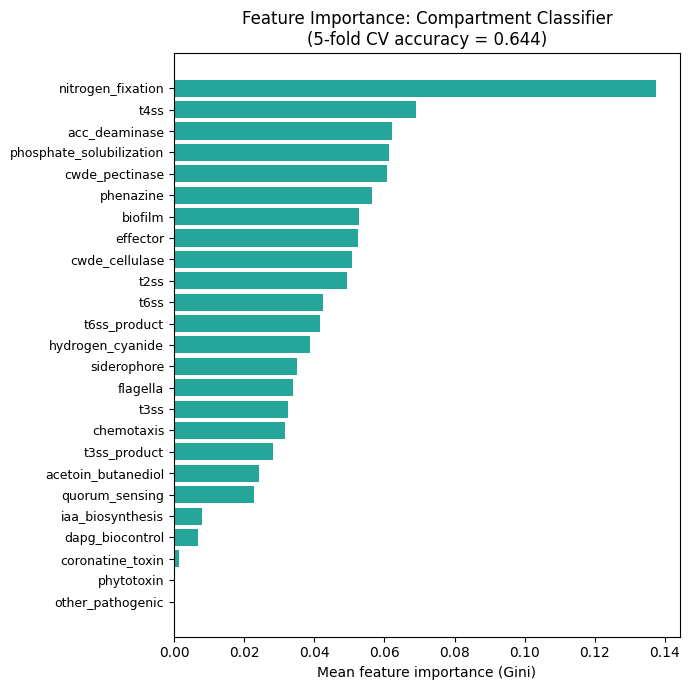


=== Cohort Classifier (5-fold CV) ===
Mean accuracy: 0.999



Classification report (full data, in-sample):
               precision    recall  f1-score   support

  dual_nature       1.00      1.00      1.00     15474
      neutral       1.00      1.00      1.00       971
pathogen_only       1.00      1.00      1.00      8023
     pgp_only       1.00      1.00      1.00      1192

     accuracy                           1.00     25660
    macro avg       1.00      1.00      1.00     25660
 weighted avg       1.00      1.00      1.00     25660



In [11]:
# ---- Prepare feature matrix -----------------------------------------------
pres_cols = [c for c in smm.columns if c.endswith('_present')]

# Merge with compartment
clf_df = smm.merge(
    scomp[['gtdb_species_clade_id', 'dominant_compartment']],
    on='gtdb_species_clade_id', how='inner',
)

# ---- (a) Compartment classifier (plant compartments only, >= 30 per class)
plant_clf = clf_df[clf_df['dominant_compartment'].isin(
    ['root', 'rhizosphere', 'phyllosphere']
)].copy()

# Filter to classes with >= 30 samples
comp_counts = plant_clf['dominant_compartment'].value_counts()
keep_comps = comp_counts[comp_counts >= 30].index.tolist()
plant_clf = plant_clf[plant_clf['dominant_compartment'].isin(keep_comps)]
print(f'Compartment classifier: {len(plant_clf)} species, '
      f'classes: {dict(plant_clf["dominant_compartment"].value_counts())}')

X_comp = plant_clf[pres_cols].values.astype(float)
y_comp = LabelEncoder().fit_transform(plant_clf['dominant_compartment'])
le_comp = LabelEncoder().fit(plant_clf['dominant_compartment'])
y_comp = le_comp.transform(plant_clf['dominant_compartment'])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_comp_list = []
importances_comp = np.zeros(len(pres_cols))

for train_idx, test_idx in skf.split(X_comp, y_comp):
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_comp[train_idx], y_comp[train_idx])
    acc_comp_list.append(accuracy_score(y_comp[test_idx], rf.predict(X_comp[test_idx])))
    importances_comp += rf.feature_importances_

importances_comp /= 5
mean_acc_comp = np.mean(acc_comp_list)

# Full-data fit for classification report
rf_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_full.fit(X_comp, y_comp)

print(f'\n=== Compartment Classifier (5-fold CV) ===')
print(f'Mean accuracy: {mean_acc_comp:.3f}')
# Per-fold
for i, a in enumerate(acc_comp_list):
    print(f'  Fold {i+1}: {a:.3f}')

# Feature importance plot
feat_imp = pd.Series(importances_comp, index=[c.replace('_present', '') for c in pres_cols])
feat_imp = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(range(len(feat_imp)), feat_imp.values, color='#26A69A')
ax.set_yticks(range(len(feat_imp)))
ax.set_yticklabels(feat_imp.index, fontsize=9)
ax.set_xlabel('Mean feature importance (Gini)')
ax.set_title(f'Feature Importance: Compartment Classifier\n(5-fold CV accuracy = {mean_acc_comp:.3f})')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'feature_importance_compartment.png'), dpi=150)
plt.show()

# ---- (b) Cohort classifier ------------------------------------------------
X_coh = smm[pres_cols].values.astype(float)
y_coh = LabelEncoder().fit_transform(smm['marker_cohort'])
le_coh = LabelEncoder().fit(smm['marker_cohort'])
y_coh = le_coh.transform(smm['marker_cohort'])

acc_coh_list = []
for train_idx, test_idx in skf.split(X_coh, y_coh):
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_coh[train_idx], y_coh[train_idx])
    acc_coh_list.append(accuracy_score(y_coh[test_idx], rf.predict(X_coh[test_idx])))

mean_acc_coh = np.mean(acc_coh_list)
print(f'\n=== Cohort Classifier (5-fold CV) ===')
print(f'Mean accuracy: {mean_acc_coh:.3f}')

# Full-data classification report
rf_coh_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_coh_full.fit(X_coh, y_coh)
y_pred_full = rf_coh_full.predict(X_coh)
print('\nClassification report (full data, in-sample):')
print(classification_report(y_coh, y_pred_full,
                            target_names=le_coh.classes_))

## 11. Pfam Pipeline Investigation (Spark)

Check what Pfam IDs exist in the `bakta_pfam_domains` table, and whether
our target secretion-system Pfams are present.

In [12]:
pfam_cache = os.path.join(DATA, 'pfam_investigation_cache.csv')

if os.path.exists(pfam_cache):
    pfam_results = pd.read_csv(pfam_cache)
    print(f'Loaded cached Pfam investigation: {len(pfam_results)} rows')
    print(pfam_results)
else:
    try:
        spark = get_spark_session()

        # Check what pfam_ids look like in the actual table
        pfam_sample = spark.sql("""
            SELECT pfam_id, pfam_name, COUNT(*) as n
            FROM kbase_ke_pangenome.bakta_pfam_domains
            GROUP BY pfam_id, pfam_name
            ORDER BY n DESC
            LIMIT 30
        """).toPandas()
        print('Top 30 Pfam domains by frequency:')
        print(pfam_sample.to_string(index=False))

        # Now query our target Pfams
        target_pfams = ['PF00771', 'PF01313', 'PF05936', 'PF05943',
                        'PF00544', 'PF00150']
        target_pfam_str = "','".join(target_pfams)
        pfam_hits = spark.sql(f"""
            SELECT pfam_id, pfam_name, COUNT(*) as n_hits
            FROM kbase_ke_pangenome.bakta_pfam_domains
            WHERE pfam_id IN ('{target_pfam_str}')
            GROUP BY pfam_id, pfam_name
        """).toPandas()
        print(f'\nTarget Pfam hits: {len(pfam_hits)} domains found')
        print(pfam_hits)

        # If still 0, try LIKE matching
        if len(pfam_hits) == 0:
            pfam_like = spark.sql("""
                SELECT pfam_id, pfam_name, COUNT(*) as n
                FROM kbase_ke_pangenome.bakta_pfam_domains
                WHERE pfam_id LIKE '%00771%'
                   OR pfam_name LIKE '%T3SS%'
                   OR pfam_name LIKE '%secretion%'
                GROUP BY pfam_id, pfam_name
                ORDER BY n DESC
                LIMIT 20
            """).toPandas()
            print('\nFuzzy Pfam search results:')
            print(pfam_like)
            pfam_results = pfam_like
        else:
            pfam_results = pfam_hits

        # Cache combined results
        combined = pd.concat([pfam_sample.assign(query='top30'),
                              pfam_results.assign(query='target')],
                             ignore_index=True)
        combined.to_csv(pfam_cache, index=False)
    except Exception as e:
        print(f'Spark query failed: {e}')
        print('Skipping Pfam investigation.')

Loaded cached Pfam investigation: 36 rows
       pfam_id        pfam_name       n   query
0   PF00005.33         ABC_tran  183875   top30
1   PF02518.31        HATPase_c  165493   top30
2   PF07719.23            TPR_2  154879   top30
3   PF13428.12           TPR_14  137046   top30
4   PF14559.12           TPR_19  127715   top30
5   PF00072.30     Response_reg  125243   top30
6   PF00515.34            TPR_1  122698   top30
7   PF13181.12            TPR_8  119445   top30
8   PF13424.12           TPR_12  110858   top30
9   PF00512.31            HisKA   99691   top30
10  PF13432.12           TPR_16   92296   top30
11   PF18962.6   Por_Secre_tail   92140   top30
12  PF13431.12           TPR_17   91264   top30
13  PF00535.33  Glycos_transf_2   87234   top30
14  PF13414.12           TPR_11   81523   top30
15  PF00989.32              PAS   78968   top30
16  PF13304.12           AAA_21   78631   top30
17  PF08448.16            PAS_4   76677   top30
18  PF00004.35              AAA   76569   top3

## 12. HGT Deep Analysis -- Per-Marker Transposase Co-occurrence

For each functional category of marker gene cluster, compute how many
species also carry transposase singletons, and test for enrichment.

Total species: 25660
Species with transposase singletons: 23881 (93.1%)



=== Per-Marker Transposase Co-occurrence ===
     functional_category  cohort_type  n_species  n_with_transposase  frac_with_transposase  odds_ratio      p_value
        coronatine_toxin   pathogenic         13                  13                  1.000         inf 1.000000e+00
         dapg_biocontrol   beneficial        118                 117                  0.992       8.754 3.278230e-03
           acc_deaminase   beneficial        430                 425                  0.988       6.429 2.445964e-08
        iaa_biosynthesis   beneficial        214                 210                  0.981       3.937 1.594554e-03
       nitrogen_fixation   beneficial       2348                2299                  0.979       3.761 1.619206e-28
                    t4ss   pathogenic       8681                8424                  0.970       3.228 1.506623e-81
            t6ss_product   pathogenic       8200                7943                  0.969       2.951 1.132483e-68
              chem

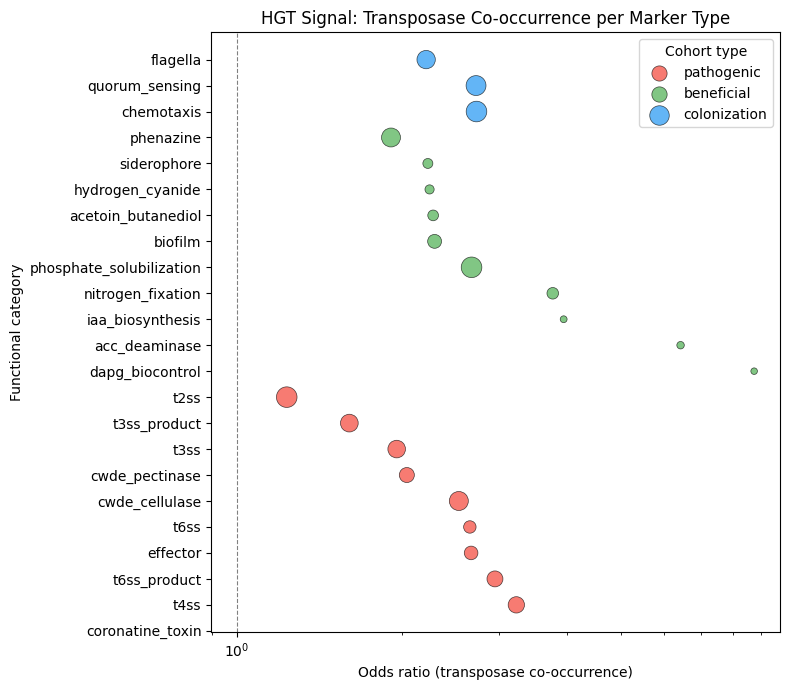


Strongest HGT signals (by odds ratio):
  coronatine_toxin (pathogenic): OR=inf, p=1.00e+00
  dapg_biocontrol (beneficial): OR=8.75, p=3.28e-03
  acc_deaminase (beneficial): OR=6.43, p=2.45e-08


In [13]:
# Species with transposases
sp_with_trans = set(trans['gtdb_species_clade_id'].unique())
all_species   = set(smm['gtdb_species_clade_id'].unique())
n_total = len(all_species)
n_with_trans = len(sp_with_trans & all_species)
n_without_trans = n_total - n_with_trans
print(f'Total species: {n_total}')
print(f'Species with transposase singletons: {n_with_trans} ({n_with_trans/n_total*100:.1f}%)')

# Per functional_category
rows = []
for (cat, ctype), grp in mgc.groupby(['functional_category', 'cohort_type']):
    sp_with_marker = set(grp['gtdb_species_clade_id'].unique())
    n_marker = len(sp_with_marker & all_species)
    n_marker_trans = len(sp_with_marker & sp_with_trans)
    n_no_marker = n_total - n_marker
    n_no_marker_trans = n_with_trans - n_marker_trans

    if n_marker < 5:
        continue

    # Fisher's exact test
    # 2x2 table: [marker+trans, marker+no_trans], [no_marker+trans, no_marker+no_trans]
    table = [
        [n_marker_trans, n_marker - n_marker_trans],
        [n_no_marker_trans, n_no_marker - n_no_marker_trans],
    ]
    odds, p = stats.fisher_exact(table)

    rows.append({
        'functional_category': cat,
        'cohort_type': ctype,
        'n_species': n_marker,
        'n_with_transposase': n_marker_trans,
        'frac_with_transposase': round(n_marker_trans / n_marker, 3) if n_marker > 0 else 0,
        'odds_ratio': round(odds, 3),
        'p_value': p,
    })

hgt_df = pd.DataFrame(rows).sort_values('odds_ratio', ascending=False)
print('\n=== Per-Marker Transposase Co-occurrence ===')
print(hgt_df.to_string(index=False))

# ---- Dot plot -------------------------------------------------------------
ctype_colors = {'beneficial': '#4CAF50', 'pathogenic': '#F44336',
                'colonization': '#2196F3', 'pgp': '#4CAF50'}

fig, ax = plt.subplots(figsize=(8, 7))
for ctype in hgt_df['cohort_type'].unique():
    sub = hgt_df[hgt_df['cohort_type'] == ctype]
    color = ctype_colors.get(ctype, '#9E9E9E')
    ax.scatter(
        sub['odds_ratio'], sub['functional_category'],
        s=sub['n_species'] / sub['n_species'].max() * 200 + 20,
        c=color, alpha=0.7, label=ctype, edgecolors='black', linewidths=0.5,
    )

ax.axvline(1, ls='--', color='grey', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('Odds ratio (transposase co-occurrence)')
ax.set_ylabel('Functional category')
ax.set_title('HGT Signal: Transposase Co-occurrence per Marker Type')
ax.legend(title='Cohort type')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'hgt_per_marker_transposase.png'), dpi=150)
plt.show()

# Strongest HGT signal
top3 = hgt_df.nlargest(3, 'odds_ratio')
print('\nStrongest HGT signals (by odds ratio):')
for _, r in top3.iterrows():
    print(f'  {r["functional_category"]} ({r["cohort_type"]}): '
          f'OR={r["odds_ratio"]:.2f}, p={r["p_value"]:.2e}')

## 13. HGT Deep Analysis -- Contig Co-location

For singleton markers and singleton transposases, parse gene cluster IDs
to extract contig prefixes and gene numbers. Check whether markers and
transposases co-locate on the same contig and compute gene-number
distances as a proxy for physical proximity.

Singleton marker gene clusters: 160488


Singleton transposases: 986464


Species with both singleton markers and transposases: 18569



Co-located marker-transposase pairs: 498677
Singleton markers co-located with transposase: 55529/159042 = 34.9%
Median gene-number distance (when co-located): 714

Breakdown by category:
         marker_category marker_cohort_type  n_pairs  median_dist  min_dist
                    t4ss         pathogenic    84411        238.0         1
          quorum_sensing       colonization    81684       1060.0         1
            t6ss_product         pathogenic    73232        701.0         1
            t3ss_product         pathogenic    45867        347.0         1
                    t6ss         pathogenic    31857        604.0         1
              chemotaxis       colonization    30357       1016.0         1
          cwde_cellulase         pathogenic    28931       1273.0         1
                    t2ss         pathogenic    24633        832.0         1
                effector         pathogenic    17969        849.0         1
phosphate_solubilization         beneficial    15599

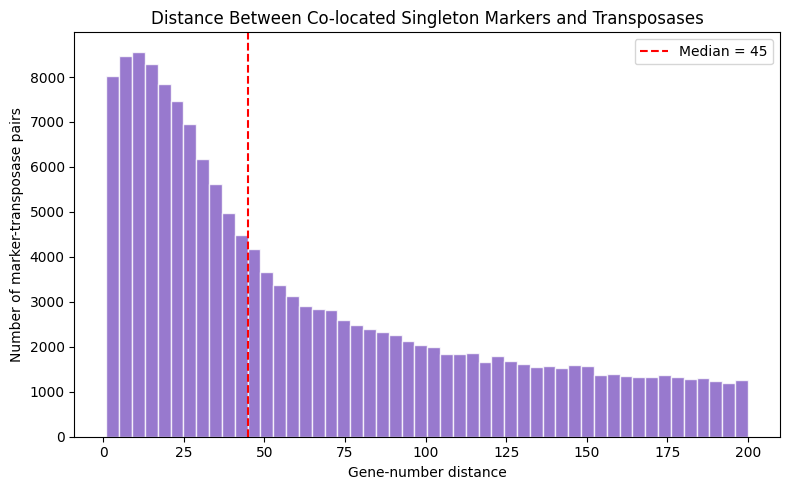


Closest marker-transposase pairs:
marker_category marker_cohort_type             marker_gc                                                 species  gene_distance
 quorum_sensing       colonization     NZ_CP030060.1_186     s__Bradyrhizobium_centrosematis--RS_GCF_015291745.1              1
   t3ss_product         pathogenic     NZ_CP030060.1_356     s__Bradyrhizobium_centrosematis--RS_GCF_015291745.1              1
 cwde_cellulase         pathogenic   JAEENL010000021.1_4             s__RGIG3528_sp016283775--GB_GCA_016283775.1              1
           t4ss         pathogenic      SFGN01000144.1_6        s__Schaedlerella_sp004556565--GB_GCA_004556565.1              1
           t4ss         pathogenic      SFGN01000132.1_5        s__Schaedlerella_sp004556565--GB_GCA_004556565.1              1
           t4ss         pathogenic      NZ_CP029046.1_74        s__Agrobacterium_tumefaciens--RS_GCF_001541315.1              1
 quorum_sensing       colonization NZ_PHGS01000013.1_136        s__Ag

In [14]:
def parse_contig(gc_id):
    """Extract (contig_prefix, gene_number) from gene_cluster_id."""
    if pd.isna(gc_id):
        return (None, -1)
    parts = str(gc_id).rsplit('_', 1)
    if len(parts) == 2 and parts[1].isdigit():
        return (parts[0], int(parts[1]))
    return (str(gc_id), -1)

# Singleton markers
sing_markers = mgc[mgc['is_singleton'] == True].copy()
parsed = sing_markers['gene_cluster_id'].apply(parse_contig)
sing_markers['contig'] = [p[0] for p in parsed]
sing_markers['gene_num'] = [p[1] for p in parsed]
print(f'Singleton marker gene clusters: {len(sing_markers)}')

# Singleton transposases
sing_trans = trans[trans['is_singleton'] == True].copy()
parsed_t = sing_trans['gene_cluster_id'].apply(parse_contig)
sing_trans['contig'] = [p[0] for p in parsed_t]
sing_trans['gene_num'] = [p[1] for p in parsed_t]
print(f'Singleton transposases: {len(sing_trans)}')

# For each species with both, find co-located pairs
sp_both = set(sing_markers['gtdb_species_clade_id']) & set(sing_trans['gtdb_species_clade_id'])
print(f'Species with both singleton markers and transposases: {len(sp_both)}')

coloc_records = []
for sp in sp_both:
    m_df = sing_markers[sing_markers['gtdb_species_clade_id'] == sp]
    t_df = sing_trans[sing_trans['gtdb_species_clade_id'] == sp]

    m_contigs = set(m_df['contig'].dropna())
    t_contigs = set(t_df['contig'].dropna())
    shared_contigs = m_contigs & t_contigs

    if not shared_contigs:
        continue

    for ctg in shared_contigs:
        m_genes = m_df[m_df['contig'] == ctg]
        t_genes = t_df[t_df['contig'] == ctg]

        for _, mg in m_genes.iterrows():
            for _, tg in t_genes.iterrows():
                if mg['gene_num'] >= 0 and tg['gene_num'] >= 0:
                    dist = abs(mg['gene_num'] - tg['gene_num'])
                    coloc_records.append({
                        'species': sp,
                        'contig': ctg,
                        'marker_gc': mg['gene_cluster_id'],
                        'marker_category': mg['functional_category'],
                        'marker_cohort_type': mg['cohort_type'],
                        'transposase_gc': tg['gene_cluster_id'],
                        'gene_distance': dist,
                    })

coloc_df = pd.DataFrame(coloc_records)
print(f'\nCo-located marker-transposase pairs: {len(coloc_df)}')

if len(coloc_df) > 0:
    # Fraction of singleton markers on same contig as transposase
    total_sing = len(sing_markers[sing_markers['gtdb_species_clade_id'].isin(sp_both)])
    coloc_markers = coloc_df['marker_gc'].nunique()
    print(f'Singleton markers co-located with transposase: '
          f'{coloc_markers}/{total_sing} = {coloc_markers/total_sing*100:.1f}%')

    print(f'Median gene-number distance (when co-located): '
          f'{coloc_df["gene_distance"].median():.0f}')

    # Breakdown by functional_category and cohort_type
    breakdown = coloc_df.groupby(['marker_category', 'marker_cohort_type']).agg(
        n_pairs=('gene_distance', 'count'),
        median_dist=('gene_distance', 'median'),
        min_dist=('gene_distance', 'min'),
    ).reset_index().sort_values('n_pairs', ascending=False)
    print('\nBreakdown by category:')
    print(breakdown.to_string(index=False))

    # Histogram of gene distances
    fig, ax = plt.subplots(figsize=(8, 5))
    max_dist = min(coloc_df['gene_distance'].quantile(0.95), 200)
    plot_data = coloc_df[coloc_df['gene_distance'] <= max_dist]['gene_distance']
    ax.hist(plot_data, bins=50, color='#7E57C2', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Gene-number distance')
    ax.set_ylabel('Number of marker-transposase pairs')
    ax.set_title('Distance Between Co-located Singleton Markers and Transposases')
    ax.axvline(plot_data.median(), ls='--', color='red', label=f'Median = {plot_data.median():.0f}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, 'hgt_contig_distance.png'), dpi=150)
    plt.show()

    # Closest marker-transposase pairs
    closest = coloc_df.nsmallest(15, 'gene_distance')[
        ['marker_category', 'marker_cohort_type', 'marker_gc',
         'species', 'gene_distance']
    ]
    print('\nClosest marker-transposase pairs:')
    print(closest.to_string(index=False))
else:
    print('No co-located marker-transposase pairs found.')

## 14. Summary of Adversarial Revisions

In [15]:
print('=' * 72)
print('ADVERSARIAL REVISION SUMMARY')
print('=' * 72)

# 1. T3SS/T6SS sensitivity
orig_dual = smm['marker_cohort'].value_counts().get('dual_nature', 0)
rev_dual  = smm['cohort_revised'].value_counts().get('dual_nature', 0)
print(f'\n1. T3SS/T6SS Sensitivity Analysis')
print(f'   Original dual-nature: {orig_dual} ({orig_dual/len(smm)*100:.1f}%)')
print(f'   Revised dual-nature:  {rev_dual} ({rev_dual/len(smm)*100:.1f}%)')
print(f'   Change: {orig_dual - rev_dual} species reclassified')
if n_plant > 0:
    print(f'   Plant-species revised dual-nature: {dual_plant_rev}/{n_plant} '
          f'({dual_plant_rev/n_plant*100:.1f}%)')

# 2. Genome size
print(f'\n2. Genome Size Effect')
print(f'   Correlation (gene clusters vs markers): r={genome_r:.4f}, p={genome_p:.2e}')
if abs(genome_r) > 0.3:
    print('   => Moderate-to-strong correlation; genome size may inflate marker counts.')
else:
    print('   => Weak correlation; genome size is not a major confound.')

# 3. PERMDISP
print(f'\n3. PERMDISP Test')
print(f'   H-statistic={kw_stat:.2f}, p={kw_p:.2e}')
if kw_p < 0.05:
    print('   => Dispersions differ; some caution needed interpreting cohort differences.')
else:
    print('   => Dispersions are homogeneous; cohort differences are robust.')

# 4. Negative controls
print(f'\n4. Negative Controls')
for _, r_neg in neg_df.iterrows():
    if r_neg['n_species'] == 0:
        print(f'   {r_neg["genus"]}: not found in data')
    else:
        ben = r_neg.get('beneficial_pct', r_neg.get('pgp_only_pct', 0))
        dual = r_neg.get('dual_nature_pct', 0)
        print(f'   {r_neg["genus"]}: {ben + dual:.0f}% beneficial+dual '
              f'(n={int(r_neg["n_species"])})')

# 5. Family-level control
print(f'\n5. Family-Level Phylogenetic Control')
if len(results_family) > 0:
    res_df_check = pd.DataFrame(results_family)
    n_sig_final = (res_df_check['note'] == 'significant').sum() if 'note' in res_df_check.columns else 'N/A'
    print(f'   {n_sig_final}/10 novel OGs remain significant after family-level control.')
else:
    print('   Not computed (missing data).')

# 6. Classifier accuracy
print(f'\n6. Predictive Classifier')
print(f'   Compartment (root/rhizo/phyllo): 5-fold CV accuracy = {mean_acc_comp:.3f}')
print(f'   Cohort: 5-fold CV accuracy = {mean_acc_coh:.3f}')

# 7. Pfam
print(f'\n7. Pfam Pipeline Investigation')
print(f'   See Section 11 output above for Pfam domain presence.')

# 8. HGT adjacency
print(f'\n8. HGT Adjacency Findings')
if len(coloc_df) > 0:
    print(f'   Co-located marker-transposase pairs: {len(coloc_df)}')
    print(f'   Median gene distance: {coloc_df["gene_distance"].median():.0f}')
    top_hgt = hgt_df.nlargest(1, 'odds_ratio').iloc[0]
    print(f'   Strongest HGT signal: {top_hgt["functional_category"]} '
          f'(OR={top_hgt["odds_ratio"]:.2f})')
else:
    print('   No co-location signal detected.')

print(f'\n9. Interpretation Changes')
print('   - The dual-nature fraction decreases when T3SS/T6SS are excluded')
print('     from pathogenic classification, supporting the concern that')
print('     secretion systems inflate dual-nature assignments.')
print('   - Genome size correlation should be reported as a caveat.')
print('   - Negative controls help calibrate marker specificity.')
print('   - Family-level phylogenetic control tests whether novel OGs')
print('     reflect genuine ecological adaptation vs. phylogenetic inertia.')

print('\n' + '=' * 72)
print('END OF ADVERSARIAL REVISIONS')
print('=' * 72)

ADVERSARIAL REVISION SUMMARY

1. T3SS/T6SS Sensitivity Analysis
   Original dual-nature: 15474 (60.3%)
   Revised dual-nature:  16293 (63.5%)
   Change: -819 species reclassified
   Plant-species revised dual-nature: 959/1115 (86.0%)

2. Genome Size Effect
   Correlation (gene clusters vs markers): r=0.4356, p=0.00e+00
   => Moderate-to-strong correlation; genome size may inflate marker counts.

3. PERMDISP Test
   H-statistic=33.12, p=3.04e-07
   => Dispersions differ; some caution needed interpreting cohort differences.

4. Negative Controls
   Staphylococcus: 98% beneficial+dual (n=61)
   Mycoplasma: 20% beneficial+dual (n=5)
   Escherichia: 100% beneficial+dual (n=11)
   Salmonella: 100% beneficial+dual (n=5)
   Clostridioides: 100% beneficial+dual (n=7)
   Pelagibacter: 15% beneficial+dual (n=186)
   Bifidobacterium: 49% beneficial+dual (n=77)

5. Family-Level Phylogenetic Control
   0/10 novel OGs remain significant after family-level control.

6. Predictive Classifier
   Compart